In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import MDS

%load_ext autoreload
%autoreload 2
import imp
from utils import load_animal_region_kernels, load_animal_kernels, list_regions, list_animals, filter_kernels_outliers, detect_outlier_subjects


/tmp/ipykernel_1049779/3709085984.py:10: DeprecationWarning: the imp module is deprecated in favour of importlib and slated for removal in Python 3.12; see the module's documentation for alternative uses
  import imp


In [2]:
genotypes = ['N', 'C', 'F', 'S']
genotype = 'C'
regions = list_regions(genotype)
animals = list_animals(genotype)

animal = 'CSP013'
region = 'MOs'

animal_kernel_region = load_animal_region_kernels(genotype, animal, region) # Give kernals across all units of this region
animal_kernel = load_animal_kernels(genotype, regions, animal) # Give kernals across all units contrasts and time (n_units, n_contrasts, n_time_bins)


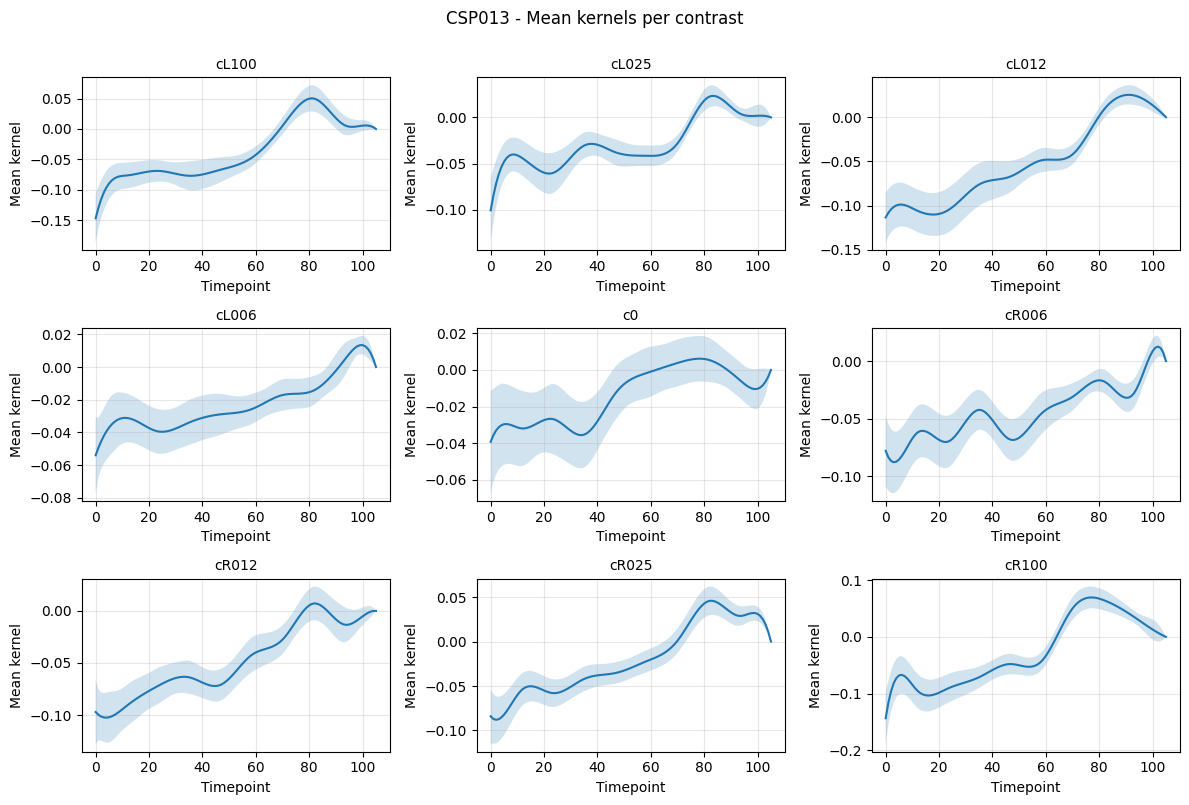

In [3]:
contrast_names = ['cL100', 'cL025', 'cL012', 'cL006', 'c0', 'cR006', 'cR012', 'cR025', 'cR100']

fig, axes = plt.subplots(3, 3, figsize=(12, 8))
axes = axes.flatten()

animal_kernel_filter = filter_kernels_outliers(animal_kernel)
for c_idx, contrast in enumerate(contrast_names):
    kernel_contrast = animal_kernel_filter[:, c_idx, :]
    mean_kernel = kernel_contrast.mean(axis=0)
    
    axes[c_idx].plot(mean_kernel, linewidth=1.5)
    sem = kernel_contrast.std(axis=0) / np.sqrt(kernel_contrast.shape[0])
    axes[c_idx].fill_between(np.arange(len(mean_kernel)), mean_kernel - sem, mean_kernel + sem, alpha=0.2)
    axes[c_idx].set_title(contrast, fontsize=10)
    axes[c_idx].grid(True, alpha=0.3)
    axes[c_idx].set_xlabel('Timepoint')
    axes[c_idx].set_ylabel('Mean kernel')

plt.suptitle(f'{animal} - Mean kernels per contrast', fontsize=12, y=1.00)
plt.tight_layout()
plt.show()

### Across all subjects/genptypes

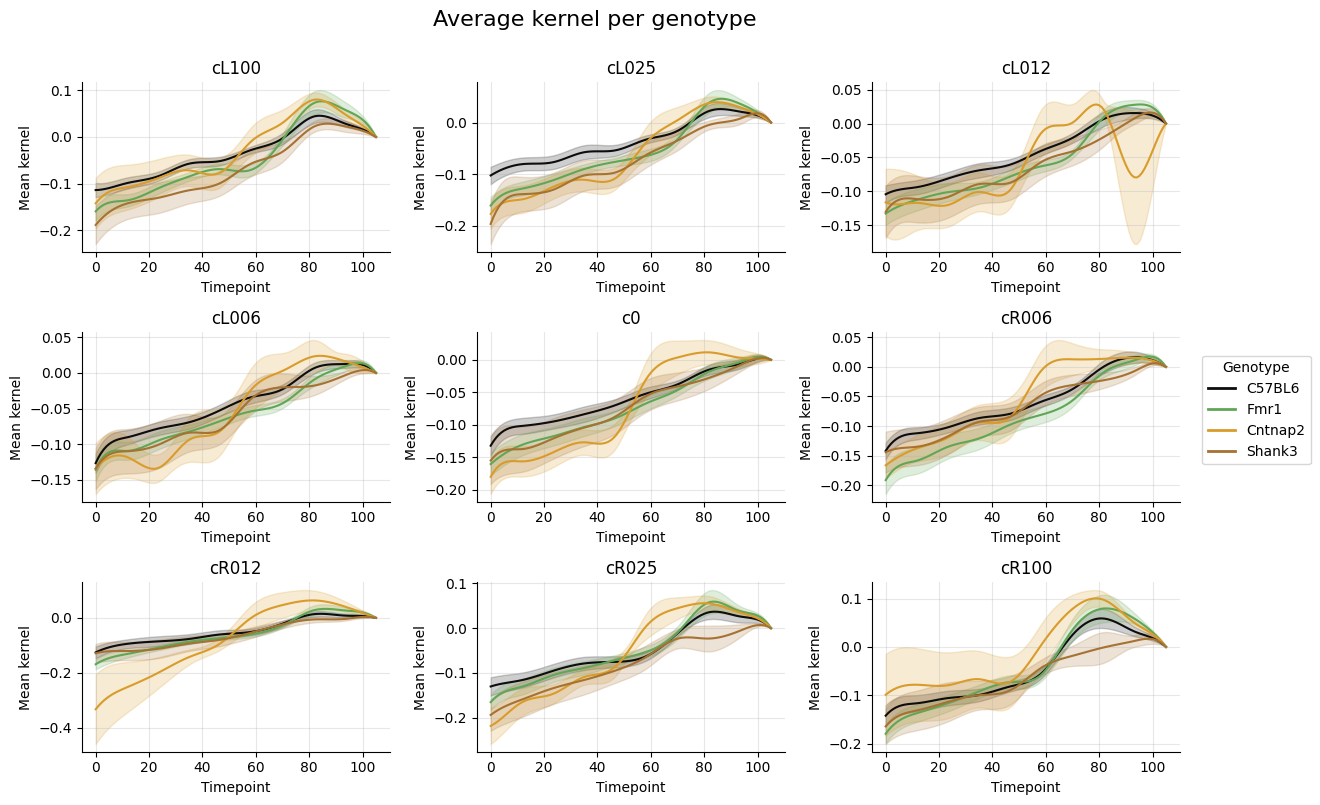

In [4]:
# Plot average kernel per genotype across all regions 
from collections import defaultdict
from matplotlib.lines import Line2D


genotypes = ['N', 'F', 'C', 'S']
contrast_names =    ['cL100', 'cL025', 'cL012', 'cL006', 'c0', 'cR006', 'cR012', 'cR025', 'cR100']
#colors = {'C':'blue', 'F':'red', 'N':'green', 'S':'orange'}
colors = {'N':'#0D0D0D', 'F':'#61A656', 'C':'#D99C2B', 'S':'#A67232'}
map_labels = {'C':'Cntnap2', 'F':'Fmr1', 'N':'C57BL6', 'S':'Shank3'}

fig, axes = plt.subplots(3, 3, figsize=(12, 8))
axes = axes.flatten()

# For each genotype, for each region, get kernel and average across all neurons
genotype_kernels_neurons = defaultdict(list)
all_animals = []
for g in genotypes:
    animals_g = list_animals(g)
    regions = list_regions(g)

    all_animals.extend(animals_g)
    for animal in animals_g:
        animal_kernel = load_animal_kernels(g, regions, animal) # (n_units, n_contrasts, n_time_bins)
        # Filter for outliers
        animal_kernel_filter = filter_kernels_outliers(animal_kernel, 97.5, 2.5)

        # If after filtering there are no more kernels left, skip this animal
        if len(animal_kernel_filter) > 0:
            genotype_kernels_neurons[g].append(animal_kernel_filter) # (subjects, n_units, contrasts, timepoints)

# Plot mean kernel across animals for each genotype and contrast - ignoring per-region and just agregating genotype
for c_idx, contrast in enumerate(contrast_names):
    ax = axes[c_idx]
    for g in genotypes:
        arrs = genotype_kernels_neurons[g]
        if len(arrs) == 0:
            continue
        vals = np.stack([a[:, c_idx, :].mean(axis=0) for a in arrs if len(a) > 0], axis=0) # (subjects, timepoints) for contrast c_idx
        mean = vals.mean(axis=0) # (n_units, timepoints)
        sem = vals.std(axis=0) / np.sqrt(vals.shape[0])
        ax.plot(mean, label=g, color=colors[g], linewidth=1.5)
        ax.fill_between(np.arange(len(mean)), mean - sem, mean + sem, color=colors[g], alpha=0.2)
    ax.set_title(contrast, fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('Timepoint')
    ax.set_ylabel('Mean kernel')

handles = [Line2D([0], [0], color=colors[g], lw=2) for g in genotypes if len(genotype_kernels_neurons[g]) > 0]
labels = [map_labels[g] for g in genotypes if len(genotype_kernels_neurons[g]) > 0]
plt.suptitle('Average kernel per genotype', fontsize=16, y=1.00)
plt.tight_layout()
sns.despine()
fig.legend(handles=handles, labels=labels, title='Genotype', bbox_to_anchor=(1, 0.5), loc='center left')
plt.show()

In [46]:
genotype_kernels_neurons['C'][0].shape

(316, 9, 106)

In [47]:
genotype_kernels_neurons['C'][1].shape

(4, 9, 106)

## Shape metrics

In [117]:
def plot_pca(dist_matrix, labels):

    # PCA on distance matrix
    pca_2d = PCA(n_components=2)
    pca_coords = pca_2d.fit_transform(dist_matrix)

    colors = {'N':'#0D0D0D', 'F':'#61A656', 'C':'#D99C2B', 'S':'#A67232'}
    map_labels = {'C':'Cntnap2', 'F':'Fmr1', 'N':'C57BL6', 'S':'Shank3'}

    fig, ax = plt.subplots(figsize=(6, 5))

    # PCA on MDS plot
    for g in np.unique(labels):
        mask = np.array(labels) == g
        ax.scatter(pca_coords[mask, 0], pca_coords[mask, 1],
                        c=colors[g], label=map_labels[g], s=60, edgecolors='white', linewidths=0.5)
    ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
    ax.set_title('PCA on MDS embedding')
    ax.legend()

    sns.despine()
    plt.tight_layout()
    plt.show()

def plot_mds_pca(dist_matrix, labels):

    # DIstance matrices are not euclidean so PCA directly is not ideal
    # MDS on the distance matrix
    mds = MDS(n_components=50, dissimilarity='precomputed', random_state=66)
    mds_coords = mds.fit_transform(dist_matrix)

    # PCA on MDS coordinates
    pca_2d = PCA(n_components=2, random_state=42)
    pca_coords = pca_2d.fit_transform(mds_coords)

    colors = {'N':'#0D0D0D', 'F':'#61A656', 'C':'#D99C2B', 'S':'#A67232'}
    map_labels = {'C':'Cntnap2', 'F':'Fmr1', 'N':'C57BL6', 'S':'Shank3'}

    fig, ax = plt.subplots(figsize=(6, 5))

    # PCA on MDS plot
    for g in np.unique(labels):
        mask = np.array(labels) == g
        ax.scatter(pca_coords[mask, 0], pca_coords[mask, 1],
                        c=colors[g], label=map_labels[g], s=60, edgecolors='white', linewidths=0.5)
    ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
    ax.set_title('PCA on MDS embedding')
    ax.legend()

    sns.despine()
    plt.tight_layout()
    plt.show()

In [6]:
# 106 time points is a lot for clustering, maybe I can split them into 10 bins and average within each bin to reduce dimensionality and noise?
def split_time_bins(arr, n_bins=10):
    """Split the last dimension of arr into n_bins and average within each bin."""
    if arr.shape[-1] % n_bins != 0:
        arr = arr[:, :, :-(arr.shape[-1] % n_bins)] # Trim the last dimension to be divisible by n_bins
    return arr.reshape(*arr.shape[:-1], n_bins, -1).mean(-1)

In [80]:
### Statistical tests

# How to test whether the distance between genotypes is significant? 
# I can do a permutation test where I shuffle the genotype labels and recompute the distance matrix

def permutation_test(dist_matrix, labels, n_perms=1000):

    # Null hypothesis: the distance between genotypes is not different from the distance within genotypes

    S = len(labels)

    # Masks for within/between genotype distances
    within_mask = np.zeros((S, S), dtype=bool)
    between_mask = np.zeros((S, S), dtype=bool)
    for i in range(S):
        for j in range(S):
            if i != j:
                if labels[i] == labels[j]:
                    within_mask[i, j] = True
                else:
                    between_mask[i, j] = True

    obs_stat = dist_matrix[between_mask].mean() - dist_matrix[within_mask].mean()

    # Permutation null distribution
    perm_stats = np.zeros(n_perms)
    for k in range(n_perms):
        perm_labels = np.random.permutation(labels)
        # Permute the masks according to the permuted labels
        wm = np.array([[perm_labels[i] == perm_labels[j] and i != j for j in range(S)] for i in range(S)])
        bm = np.array([[perm_labels[i] != perm_labels[j] for j in range(S)] for i in range(S)])
        perm_stats[k] = dist_matrix[bm].mean() - dist_matrix[wm].mean()

    p_value = np.mean(perm_stats >= obs_stat)
    print(f"Observed statistic (between - within): {obs_stat:.4f}")
    print(f"p-value: {p_value:.4f}")

    return p_value, perm_stats, obs_stat

### Using the 100 least variable neurons

In [26]:
# What can i do now? I can maybe try to cluster the kernels across genotypes
# Maybe I can, instead of using all neurons, selecting just the areas in common?

all_subjects = []
all_genotypes=[]
for g in genotypes:
    arrs = genotype_kernels_neurons[g]
    if len(arrs) == 0:
        continue
        
    # Get the 100 least variable neurons across all animals for this genotype and contrast
    vals = [a[np.argsort(a.std(axis=(1,2)))[:100], :, :] for a in arrs if len(a) >= 100] # (neurons, contrasts, timepoints) for each subject

    if g=='C':
        # Remove the first subject of C because it has a very different activity and messes with the clustering
        vals.pop(3)

    # spLIT ACROSS TIME BINS
    #vals = [split_time_bins(a) for a in vals]

    all_genotypes.extend([g]*len(vals))

    # Now vals has the shape (subjects, timepoints * conditions, neurons)
    all_subjects.append(vals)

all_subjects = np.concatenate(all_subjects, axis=0) # (subjects, neurons, contrasts, timepoints)
S, n, c, t = all_subjects.shape
all_subjects_reshaped = all_subjects.reshape(S, n, c*t).transpose(0,2,1) # (subjects, contrast*timepoints, neurons)
#all_subjects_reshaped = all_subjects.mean(-1).transpose(0,2,1) # (subjects, contrast, neurons)

In [24]:
all_subjects_reshaped.shape

(34, 954, 100)

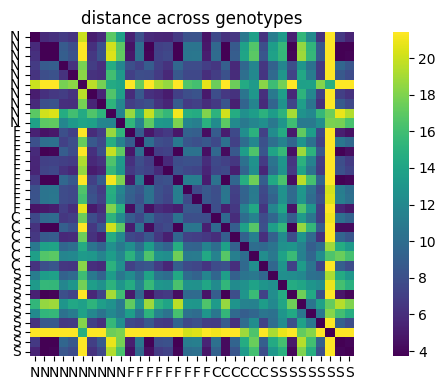

In [27]:
from matplotlib.colors import Normalize

from metric import dsd
S = len(all_subjects_reshaped)
dist_neural = dsd([
    [all_subjects_reshaped[i],all_subjects_reshaped[j]]
    for i in range(S) 
    for j in range(S)]
    ).reshape(S,S)

fig, ax = plt.subplots(1, 1, figsize=(8, 4))

vmin = np.quantile(dist_neural.flatten(), 0.05)  # 5th percentile
vmax = np.quantile(dist_neural.flatten(), 0.95)  # 95th percentile

sns.heatmap(dist_neural, xticklabels=all_genotypes, yticklabels=all_genotypes, cmap='viridis', 
            square=True, fmt='.2f', linecolor='white', norm=Normalize(vmin, vmax))

plt.title('distance across genotypes', fontsize=12)
plt.yticks(rotation=0, fontsize=10)
plt.xticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.show()

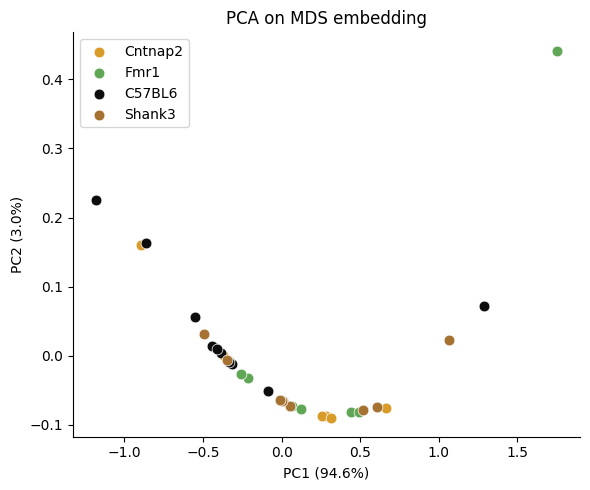

In [181]:
plot_mds_pca(dist_neural, all_genotypes)

### Using all neurons

In [93]:
# What can i do now? I can maybe try to cluster the kernels across genotypes
# Maybe I can, instead of using all neurons, selecting just the areas in common?

all_subjects = []
all_genotypes=[]
for g in genotypes:
    arrs = genotype_kernels_neurons[g]
    if len(arrs) == 0:
        continue
        
    # Just filter out the subjects with less than 100 neurons, but keep all neurons
    vals = [a.reshape(a.shape[0], -1).T for a in arrs if len(a) >= 100] # (n_neurons, contrast*timepoints) for each subject

    # Maybe do a mean across all time points?
    #als = [a.mean(-1).T for a in arrs if len(a) >= 100]

    """if g=='C':
        # Remove the last subject of C because it has a very different activity and messes with the clustering
        vals.pop(3)"""

    all_genotypes.extend([g]*len(vals))

    # Now vals has the shape (subjects, timepoints * conditions, neurons)
    all_subjects.extend(vals)


In [97]:
all_subjects[1].shape

(954, 821)

In [ ]:
from matplotlib.colors import Normalize

from metric import dsd
S = len(all_subjects)
dist_neural = dsd([
    [all_subjects[i].T, all_subjects[j].T]
    for i in range(S) 
    for j in range(S)]
    ).reshape(S,S)

fig, ax = plt.subplots(1, 1, figsize=(8, 4))

vmin = np.quantile(dist_neural.flatten(), 0.05)  # 5th percentile
vmax = np.quantile(dist_neural.flatten(), 0.95)  # 95th percentile

sns.heatmap(dist_neural, xticklabels=all_genotypes, yticklabels=all_genotypes, cmap='viridis', 
            square=True, fmt='.2f', linecolor='white', norm=Normalize(vmin, vmax))

plt.title('distance across genotypes', fontsize=12)
plt.yticks(rotation=0, fontsize=10)
plt.xticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.show()

RayTaskError(ValueError): [36mray::_deterministic_metrics_pair()[39m (pid=1051455, ip=10.12.12.12)
  File "/home/blopes/ShapeMetrics/ibl_autism/metric.py", line 35, in _deterministic_metrics_pair
    metric.fit(Xi,Xj)
  File "/home/blopes/.pyenv/versions/ibl/lib/python3.10/site-packages/netrep/metrics/linear.py", line 111, in fit
    X, Y = check_equal_shapes(X, Y, nd=2, zero_pad=self.zero_pad)
  File "/home/blopes/.pyenv/versions/ibl/lib/python3.10/site-packages/netrep/validation.py", line 45, in check_equal_shapes
    raise ValueError(
ValueError: Expected arrays with equal dimensions, but got arrays with shapes (339, 954) and (821, 954).

2026-04-23 15:10:28,525	ERROR worker.py:439 -- Unhandled error (suppress with 'RAY_IGNORE_UNHANDLED_ERRORS=1'): ray::_deterministic_metrics_pair() (pid=1051475, ip=10.12.12.12)
  File "/home/blopes/ShapeMetrics/ibl_autism/metric.py", line 35, in _deterministic_metrics_pair
    metric.fit(Xi,Xj)
  File "/home/blopes/.pyenv/versions/ibl/lib/python3.10/site-packages/netrep/metrics/linear.py", line 111, in fit
    X, Y = check_equal_shapes(X, Y, nd=2, zero_pad=self.zero_pad)
  File "/home/blopes/.pyenv/versions/ibl/lib/python3.10/site-packages/netrep/validation.py", line 45, in check_equal_shapes
    raise ValueError(
ValueError: Expected arrays with equal dimensions, but got arrays with shapes (559, 954) and (435, 954).


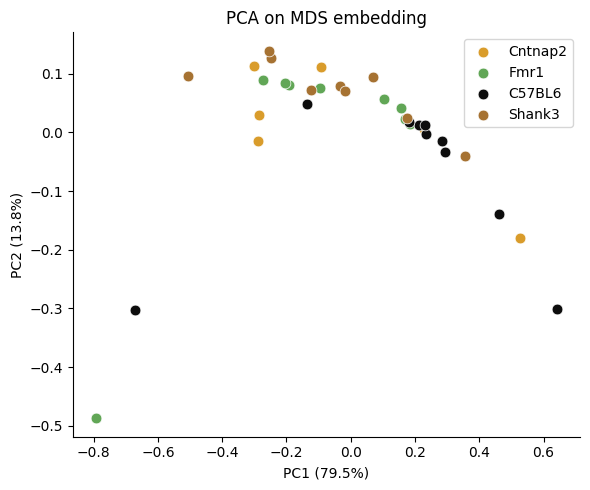

In [34]:
plot_mds_pca(dist_neural, all_genotypes)

### Using PCA to choose the best neurons

In [100]:
n_comp = 100  # shared dim

all_subjects = []
all_genotypes = []
for g in genotypes:
    arrs = genotype_kernels_neurons[g]
    if len(arrs) == 0:
        continue

    # For each subject
    for a in arrs:
        if len(a) < n_comp: # Exclude if too few
            continue
        n_neurons, c, t = a.shape
        X = a.reshape(n_neurons, c * t).T  # (conditions*timepoints, neurons)
        pca = PCA(n_components=min(n_comp, n_neurons, X.shape[0]))
        X_proj = pca.fit_transform(X)  # (conditions*timepoints, n_comp)
        all_subjects.append(X_proj)
        all_genotypes.append(g)

S = len(all_subjects)
all_subjects_pca = np.stack(all_subjects)  # (S, conditions*timepoints, n_comp)
all_subjects_pca_reshape = all_subjects_pca.reshape(S, c, t, n_comp).mean(2)  

In [22]:
all_subjects_pca.shape

(35, 954, 100)

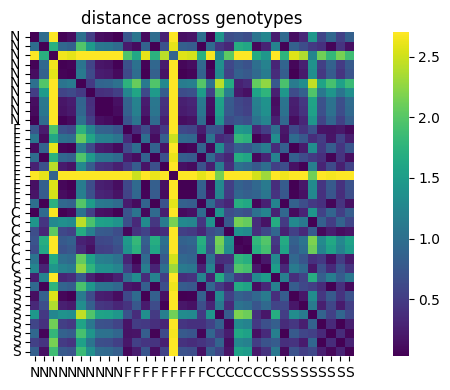

In [101]:
from matplotlib.colors import Normalize

from metric import dsd
S = len(all_subjects_pca)
dist_neural_pca = dsd([
    [all_subjects_pca_reshape[i], all_subjects_pca_reshape[j]]
    for i in range(S) 
    for j in range(S)]
    ).reshape(S,S)

fig, ax = plt.subplots(1, 1, figsize=(8, 4))

vmin = np.quantile(dist_neural_pca.flatten(), 0.05)  # 5th percentile
vmax = np.quantile(dist_neural_pca.flatten(), 0.95)  # 95th percentile

sns.heatmap(dist_neural_pca, xticklabels=all_genotypes, yticklabels=all_genotypes, cmap='viridis', 
            square=True, fmt='.2f', linecolor='white', norm=Normalize(vmin, vmax))

plt.title('distance across genotypes', fontsize=12)
plt.yticks(rotation=0, fontsize=10)
plt.xticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.show()

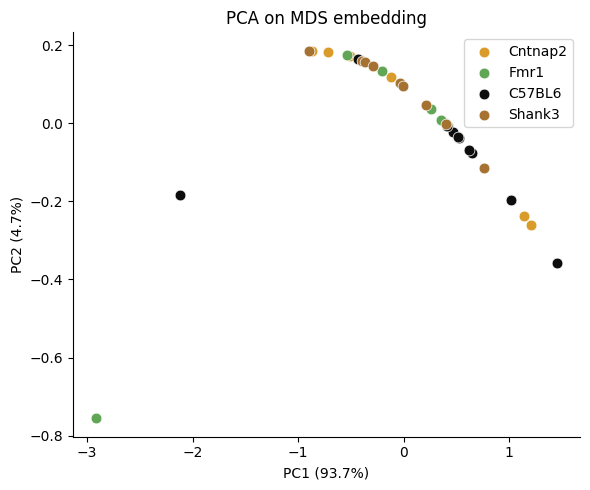

In [102]:
plot_mds_pca(dist_neural_pca, all_genotypes)


### Separate across macroregions

In [44]:
# What if i mapped each area to its macroregion, averaged the neurons across the macroregion and used this to represent the subjects?
# Like this I could have a representation that accounts for the differences in the number of neurons and the behavior of areas
area_to_macro = {
    'CA1': 'HIP', 
    'CA3': 'HIP', 
    'DG': 'HIP', 
    'POST': 'HIP', 
    'ProS': 'HIP', 
    'SUB': 'HIP',
    'MB': 'MB', 
    'MRN': 'MB', 
    'SC': 'MB', 
    'SNr': 'MB', 
    'PRT': 'MB',
    'ACAd': 'FC', 
    'ACAv': 'FC', 
    'MOs': 'FC',
    'MOp': 'SM', 
    'RSPd': 'SM', 
    'RSPv': 'SM',
    'CP': 'STR', 
    'LS': 'STR', 
    'TRS': 'STR', 
    'SF': 'STR',
    'LD': 'TH', 
    'LGd': 'TH', 
    'LP': 'TH', 
    'MG': 'TH', 
    'PO': 'TH', 
    'PVT': 'TH', 
    'TH': 'TH', 
    'SGN': 'TH',
    'VISa': 'VIS', 
    'VISam': 'VIS', 
    'VISp': 'VIS',
    #'P': 'Other', 
    #'PRNr': 'Other'
}

### Use common regions

In [ ]:
genotype_kernels = defaultdict(list)
all_animals = []
macro_names = sorted(set(area_to_macro.values()))

for g in genotypes:
    animals_g = list_animals(g)
    regions = list_regions(g)

    for animal in animals_g:
        # map each region to its macroregion
        macro_kernels = defaultdict(list)  # each element will be of size (n_units, n_contrasts, n_time_bins)
        
        for region in regions:
            macro = area_to_macro.get(region)
            if macro is None:
                continue

            region_kernel = load_animal_region_kernels(g, animal, region)

            if len(region_kernel) == 0:
                continue

            # Filter outliers
            region_kernel = filter_kernels_outliers(region_kernel, 95, 5)
            macro_kernels[macro].append(region_kernel)

        # Average neurons within each macroregion -> (n_macroregions, n_contrasts, n_time_bins)
        macro_avg = []
        for macro in macro_names:
            # For each macroregion of this subject
            if macro in macro_kernels:
                combined = np.concatenate(macro_kernels[macro], axis=0)  # (n_units, n_contrasts, n_time_bins)
                macro_avg.append(combined.mean(axis=0))  # (n_contrasts, n_time_bins)

        # Skip if not all regions are included
        # Doesnt work... it will remove all subjects of some gentypes....
        """if len(macro_avg) < len(macro_names):
            print(f"Warning: Subject {animal} of genotype {g} is missing some macroregions. Found: {list(macro_kernels.keys())}")
            continue"""

        animal_macro_kernel = np.stack(macro_avg, axis=0)  # (n_macroregions, n_contrasts, n_time_bins)
        genotype_kernels[g].append(animal_macro_kernel)

        all_animals.extend(animals_g)

# Detect and remove outlier subjects based on mean kernel amplitude
for g in genotypes:
    arrs = genotype_kernels[g]
    if len(arrs) < 3:
        continue
    keep_mask, amps = detect_outlier_subjects(arrs, mad_factor=3.0)
    n_removed = (~keep_mask).sum()
    if n_removed > 0:
        removed_idx = np.where(~keep_mask)[0]
        print(f"Genotype {g}: removing {n_removed} outlier subject(s) "
              f"(indices {removed_idx.tolist()}, amplitudes: {amps[removed_idx].round(3)})")
        genotype_kernels[g] = [a for a, m in zip(arrs, keep_mask) if m]
    else:
        print(f"Genotype {g}: no outliers (amplitudes: {amps.round(3)})")

print(f"\nMacroregions: {macro_names}")
print(f"Shape per animal: {genotype_kernels[genotypes[0]][0].shape}")  # (n_macroregions, n_contrasts, n_time_bins)


/tmp/ipykernel_3911400/1785194642.py:33: RuntimeWarning: Mean of empty slice.
  macro_avg.append(combined.mean(axis=0))  # (n_contrasts, n_time_bins)


Macroregions: ['FC', 'HIP', 'MB', 'SM', 'STR', 'TH', 'VIS']
Shape per animal: (7, 9, 106)


In [ ]:
# What can i do now? I can maybe try to cluster the kernels across genotypes
# Maybe I can, instead of using all neurons, selecting just the areas in common?

all_subjects_regions = []
all_genotypes=[]
for g in genotypes:
    arrs = genotype_kernels[g]
    if len(arrs) == 0:
        continue
        
    # Get the 100 least variable neurons across all animals for this genotype and contrast
    vals = np.stack(arrs) # (subjects, regions, contrasts, timepoints)

    all_genotypes.extend([g]*len(vals))

    # Now vals has the shape (subjects, timepoints * conditions, neurons)
    all_subjects_regions.append(vals)

all_subjects_regions = np.concatenate(all_subjects_regions, axis=0) # (subjects, regions, contrasts, timepoints)
S, r, c, t = all_subjects_regions.shape
all_subjects_regions = all_subjects_regions.reshape(S, r, c*t).transpose(0,2,1) # (subjects, contrast*timepoints, regions)
#all_subjects_reshaped = all_subjects.mean(-1).transpose(0,2,1) # (subjects, contrast, regions)


In [94]:
all_subjects_regions.shape

(13, 954, 7)

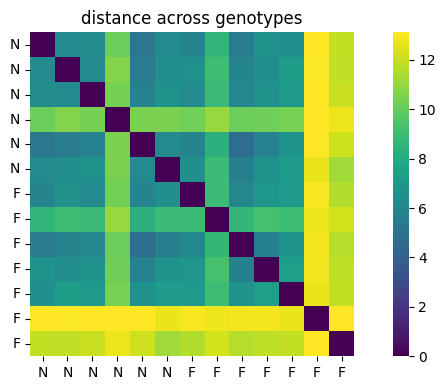

In [95]:
from matplotlib.colors import Normalize

from metric import dsd

dist_neural = dsd([
    [all_subjects_regions[i],all_subjects_regions[j]]
    for i in range(S) 
    for j in range(S)]
    ).reshape(S,S)

fig, ax = plt.subplots(1, 1, figsize=(8, 4))

vmin = np.quantile(dist_neural.flatten(), 0.05)  # 5th percentile
vmax = np.quantile(dist_neural.flatten(), 0.95)  # 95th percentile

sns.heatmap(dist_neural, xticklabels=all_genotypes, yticklabels=all_genotypes, cmap='viridis', 
            square=True, fmt='.2f', linecolor='white', norm=Normalize(vmin, vmax))

plt.title('distance across genotypes', fontsize=12)
plt.yticks(rotation=0, fontsize=10)
plt.xticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.show()

### Get just some macroregion's neurons

In [132]:
list_animals('C')

['CSP016',
 'CSP025',
 'CSP003',
 'CSP004',
 'CSP001',
 'CSP015',
 'CSP013',
 'CSP017',
 'CSP018',
 'CSP011',
 'CSP023']

In [140]:
all_animals = []
macro_names = sorted(set(area_to_macro.values()))
fc_kernels = []  # each element will be of size (n_units, n_contrasts, n_time_bins)
fc_genotypes = []

for g in genotypes:
    animals_g = list_animals(g)
    regions = list_regions(g)

    animal_fc = []
    for animal in animals_g:
        # map each region to its macroregion
        for region in regions:
            macro = area_to_macro.get(region)
            # Just take neurons from frontal regions
            if macro=='SM': # or macro=='FC' 'VIS

                region_kernel = load_animal_region_kernels(g, animal, region) # (units, contrasts, time_bins)

                if len(region_kernel) < 40: # Exclude if too few neurons (kinda arbitrary)
                    continue
            
                animal_fc.append(region_kernel) 
                # Filter outliers
        if len(animal_fc) > 0:
            # Each subject is an array of shape (n_units, n_contrasts, n_time_bins) 
            fc_kernels.append(np.concatenate(animal_fc, axis=0)) # (subjects, n_units, contrasts, timepoints)
            fc_genotypes.append(g)

In [142]:
for i, (kernels, g) in enumerate(zip(fc_kernels, fc_genotypes)):
    print(f"Subject {i} (genotype {g}): shape {kernels.shape}")

Subject 0 (genotype N): shape (40, 9, 106)
Subject 1 (genotype N): shape (40, 9, 106)
Subject 2 (genotype N): shape (99, 9, 106)
Subject 3 (genotype N): shape (144, 9, 106)
Subject 4 (genotype N): shape (144, 9, 106)
Subject 5 (genotype N): shape (144, 9, 106)
Subject 6 (genotype N): shape (144, 9, 106)
Subject 7 (genotype N): shape (144, 9, 106)
Subject 8 (genotype N): shape (144, 9, 106)
Subject 9 (genotype F): shape (45, 9, 106)
Subject 10 (genotype F): shape (45, 9, 106)
Subject 11 (genotype F): shape (45, 9, 106)
Subject 12 (genotype S): shape (42, 9, 106)
Subject 13 (genotype S): shape (186, 9, 106)
Subject 14 (genotype S): shape (186, 9, 106)


In [108]:
all_subjects_regions = [kernels_animal.mean(-1).T for kernels_animal in fc_kernels] # (subjects, contrast, regions)


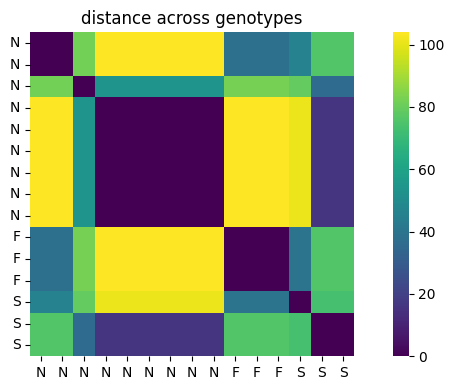

In [141]:
from matplotlib.colors import Normalize
from metric import dsd

all_subjects_regions = [kernels_animal.reshape(kernels_animal.shape[0], -1).T for kernels_animal in fc_kernels] # (subjects, contrast, regions)
S = len(all_subjects_regions)
dist_neural = dsd([
    [all_subjects_regions[i],all_subjects_regions[j]]
    for i in range(S) 
    for j in range(S)]
    ).reshape(S,S)

fig, ax = plt.subplots(1, 1, figsize=(8, 4))

vmin = np.quantile(dist_neural.flatten(), 0.05)  # 5th percentile
vmax = np.quantile(dist_neural.flatten(), 0.95)  # 95th percentile

sns.heatmap(dist_neural, xticklabels=fc_genotypes, yticklabels=fc_genotypes, cmap='viridis', 
            square=True, fmt='.2f', linecolor='white', norm=Normalize(vmin, vmax))

plt.title('distance across genotypes', fontsize=12)
plt.yticks(rotation=0, fontsize=10)
plt.xticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.show()

In [87]:
print(dist_neural[:10,:].mean(0)[:10].mean())
print(dist_neural[:10,:].mean(0)[10:].mean())

35.902940275544566
53.520794241023374


In [88]:
print(dist_neural[10:19,:].mean(0)[10:19].mean())
print(dist_neural[:10,:].mean(0)[:10].mean() + dist_neural[:10,:].mean(0)[:19].mean())

42.2841258621148
75.74331585137634


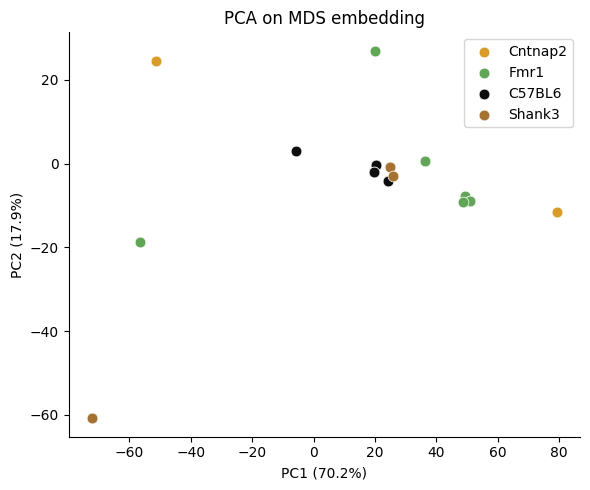

In [118]:
plot_mds_pca(dist_neural, fc_genotypes)

In [116]:
# How to test whether the distance between genotypes is significant? 
# I can do a permutation test where I shuffle the genotype labels and recompute the distance matrix

# Null hypothesis: the distance between genotypes is not different from the distance within genotypes

labels = np.array(fc_genotypes)
n_perms=10000
p_value, perm_stats, obs_stat = permutation_test(dist_neural, labels, n_perms=10000)


Observed statistic (between - within): 27.6338
p-value: 0.0000


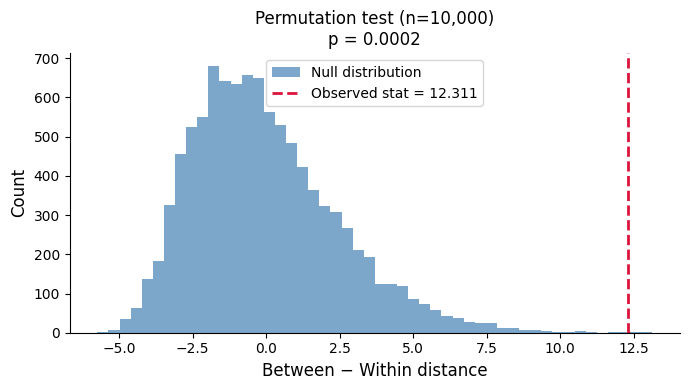

In [89]:
# Visualize the null distribution and observed statistic
fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(perm_stats, bins=50, color='steelblue', alpha=0.7, label='Null distribution')
ax.axvline(obs_stat, color='crimson', linewidth=2, linestyle='--', label=f'Observed stat = {obs_stat:.3f}')

# Shade the tail (p-value region)
tail = perm_stats[perm_stats >= obs_stat]
if len(tail) > 0:
    ax.hist(tail, bins=50, color='crimson', alpha=0.4)

ax.set_xlabel('Between − Within distance', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title(f'Permutation test (n={n_perms:,})\np = {p_value:.4f}', fontsize=12)
ax.legend(fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
# Another way could be by doing PERMANOVA (search more detailed)

from skbio.stats.distance import DistanceMatrix, permanova

dist_neural_sym = (dist_neural + dist_neural.T) / 2
dist_neural_sym[np.diag_indices_from(dist_neural_sym)] = 0
S = dist_neural_sym.shape[0]
ids = [str(i) for i in range(S)]
dm = DistanceMatrix(dist_neural_sym, ids=ids)

result = permanova(dm, fc_genotypes, permutations=10000)
print(result)

method name               PERMANOVA
test statistic name        pseudo-F
sample size                      38
number of groups                  4
test statistic             3.135907
p-value                      0.0026
number of permutations        10000
Name: PERMANOVA results, dtype: object
